In [3]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Mengambil file dari kaggle
file_path = "fordgobike-tripdataFor201902.csv"

In [5]:
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "nancyalaswad90/trip-data-ford-go-bike",
  file_path,
)

/tmp/ipython-input-1461045340.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 4.94M/4.94M [00:00<00:00, 95.5MB/s]

Extracting zip of fordgobike-tripdataFor201902.csv...


In [ ]:
print("First 5 records:", df.head()) # Melihat data

First 5 records:    duration_sec start_time end_time  start_station_id  \
0         52185    32:10.1  01:56.0              21.0   
1         42521    53:21.8  42:03.1              23.0   
2         61854    13:13.2  24:08.1              86.0   
3         36490    54:26.0  02:36.8             375.0   
4          1585    54:18.5  20:44.1               7.0   

                                 start_station_name  start_station_latitude  \
0  Montgomery St BART Station (Market St at 2nd St)               37.789625   
1                     The Embarcadero at Steuart St               37.791464   
2                           Market St at Dolores St               37.769305   
3                           Grove St at Masonic Ave               37.774836   
4                               Frank H Ogawa Plaza               37.804562   

   start_station_longitude  end_station_id  \
0              -122.400811            13.0   
1              -122.391034            81.0   
2              -122.426826 

In [ ]:
#Mengecek Kolom Kosong
df.isnull().sum()

,0
duration_sec,0
start_time,0
end_time,0
start_station_id,197
start_station_name,197
start_station_latitude,0
start_station_longitude,0
end_station_id,197
end_station_name,197
end_station_latitude,0


In [6]:
# Membuat Copy Data
df_copy = df.copy()

In [12]:
# Melakukan Pembersihan Data Kosong dengan Menggunakan Data Copy
df_clean = df_copy.dropna(subset=['start_station_id','start_station_name','end_station_id','end_station_name','member_birth_year','member_gender'])

In [13]:
df_clean.isnull().sum()

,0
duration_sec,0
start_time,0
end_time,0
start_station_id,0
start_station_name,0
start_station_latitude,0
start_station_longitude,0
end_station_id,0
end_station_name,0
end_station_latitude,0


In [36]:
# Melihat Outliers
df_clean['duration_sec'].describe()
Q1 = df_clean['duration_sec'].quantile(0.25)
Q3 = df_clean['duration_sec'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_clean[(df_clean['duration_sec'] < Q1 - 1.5*IQR) | (df_clean['duration_sec'] > Q3 + 1.5*IQR)]
print(outliers)

        duration_sec start_time end_time  start_station_id  \
0              52185    32:10.1  01:56.0                21   
2              61854    13:13.2  24:08.1                86   
3              36490    54:26.0  02:36.8               375   
4               1585    54:18.5  20:44.1                 7   
5               1793    49:58.6  19:51.8                93   
...              ...        ...      ...               ...   
183017          1589    01:40.2  28:10.1                58   
183060          1616    54:49.0  21:45.7                85   
183165          2870    07:09.6  54:59.7               304   
183326          5713    02:55.2  38:09.0                31   
183328          2822    49:07.3  36:10.2               152   

                                      start_station_name  \
0       montgomery st bart station (market st at 2nd st)   
2                                market st at dolores st   
3                                grove st at masonic ave   
4              

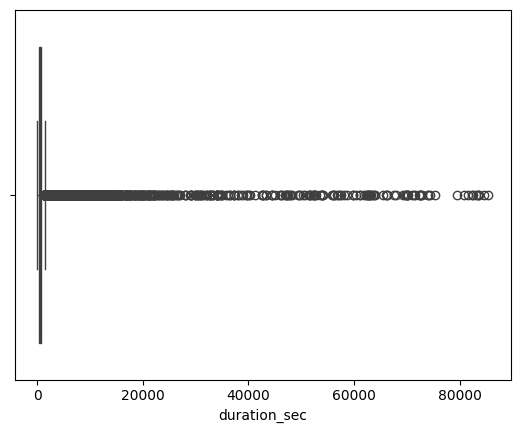

In [38]:
sns.boxplot(x=df['duration_sec'])
plt.show()

In [15]:
# Merapikan Nama Kolom
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

In [16]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174956 entries, 0 to 183415
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             174956 non-null  int64  
 1   start_time               174956 non-null  object 
 2   end_time                 174956 non-null  object 
 3   start_station_id         174956 non-null  float64
 4   start_station_name       174956 non-null  object 
 5   start_station_latitude   174956 non-null  float64
 6   start_station_longitude  174956 non-null  float64
 7   end_station_id           174956 non-null  float64
 8   end_station_name         174956 non-null  object 
 9   end_station_latitude     174956 non-null  float64
 10  end_station_longitude    174956 non-null  float64
 11  bike_id                  174956 non-null  int64  
 12  user_type                174956 non-null  object 
 13  member_birth_year        174956 non-null  float64
 14  member_ge

In [43]:
# Mengubah Tipe Data Tiap Kolom
df_clean['start_station_id'] = df_clean['start_station_id'].astype('int64')
df_clean['end_station_id'] = df_clean['end_station_id'].astype('int64')
df_clean['bike_id'] = df_clean['bike_id'].astype('int64')
df_clean['user_type'] = df_clean['user_type'].astype('category')
df_clean['member_birth_year'] = df_clean['member_birth_year'].astype('int64')
df_clean['member_gender'] = df_clean['member_gender'].astype('category')
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'], format='%M:%S.%f')
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'], format='%M:%S.%f')

In [44]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 174952 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   duration_sec             174952 non-null  int64         
 1   start_time               174952 non-null  datetime64[ns]
 2   end_time                 174952 non-null  datetime64[ns]
 3   start_station_id         174952 non-null  int64         
 4   start_station_name       174952 non-null  object        
 5   start_station_latitude   174952 non-null  float64       
 6   start_station_longitude  174952 non-null  float64       
 7   end_station_id           174952 non-null  int64         
 8   end_station_name         174952 non-null  object        
 9   end_station_latitude     174952 non-null  float64       
 10  end_station_longitude    174952 non-null  float64       
 11  bike_id                  174952 non-null  int64         
 12  user_type            

In [24]:
# Membersihkan data duplikat

df_clean = df_clean.drop_duplicates()
df_clean.duplicated().sum()

np.int64(0)

In [25]:
# Standarisasi Data
# Hapus spasi
df_clean = df_clean.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# Ubah semua string jadi lowercase
df_clean = df_clean.applymap(lambda x: x.lower() if isinstance(x, str) else x)

/tmp/ipython-input-321927571.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.strip() if isinstance(x, str) else x)
/tmp/ipython-input-321927571.py:5: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df_clean.applymap(lambda x: x.lower() if isinstance(x, str) else x)


In [26]:
# Melihat jumlah data
print("Jumlah total perjalanan:", len(df_clean))
print("Jumlah stasiun asal unik:", df_clean['start_station_name'].nunique())
print("Jumlah stasiun tujuan unik:", df_clean['end_station_name'].nunique())
print("\nDeskripsi durasi perjalanan (detik):")
print(df_clean['duration_sec'].describe())
print("\nDistribusi user type:")
print(df_clean['user_type'].value_counts())

Jumlah total perjalanan: 174952
Jumlah stasiun asal unik: 329
Jumlah stasiun tujuan unik: 329

Deskripsi durasi perjalanan (detik):
count    174952.000000
mean        704.002744
std        1642.204905
min          61.000000
25%         323.000000
50%         510.000000
75%         789.000000
max       84548.000000
Name: duration_sec, dtype: float64

Distribusi user type:
user_type
subscriber    158386
customer       16566
Name: count, dtype: int64


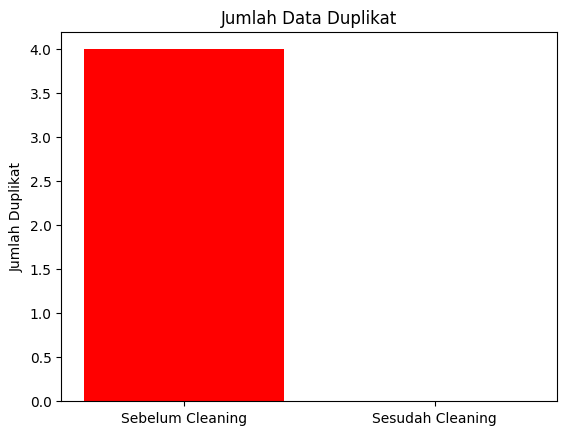

In [29]:
#Hitung Duplikat dan Visualisasi

duplikat = df.duplicated().sum()
duplikat_bersih = df_clean.duplicated().sum()

plt.bar(["Sebelum Cleaning", "Sesudah Cleaning"], [duplikat, duplikat_bersih], color=['red', 'green'])
plt.title("Jumlah Data Duplikat")
plt.ylabel("Jumlah Duplikat")
plt.show()

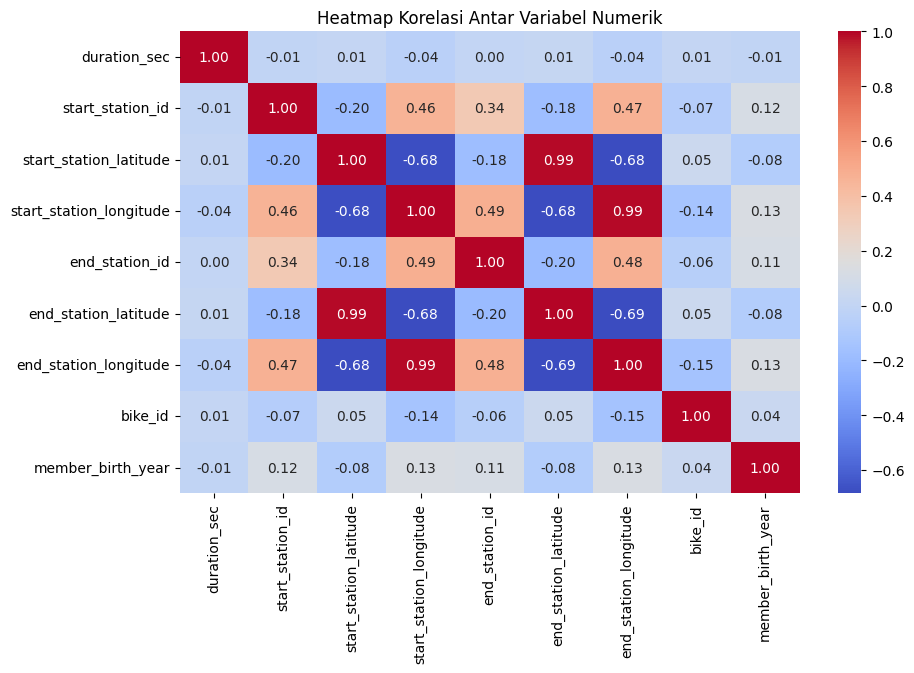

In [45]:
# Hitung korelasi hanya untuk kolom numerik
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Antar Variabel Numerik")
plt.show()

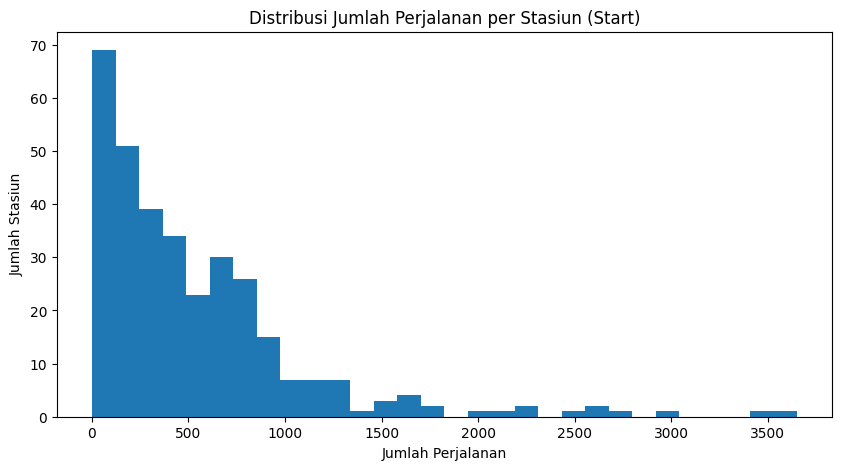

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(start_counts, bins=30)
plt.title("Distribusi Jumlah Perjalanan per Stasiun (Start)")
plt.xlabel("Jumlah Perjalanan")
plt.ylabel("Jumlah Stasiun")
plt.show()

In [ ]:
print("\nDistribusi user type:")
print(df_clean['user_type'].value_counts())

# Stasiun teramai per jenis user
start_by_user = df_clean.groupby(['user_type', 'start_station_name']).size().reset_index(name='trip_count')

# Ambil top 5 per kategori
top_stations_per_user = start_by_user.sort_values(['user_type','trip_count'], ascending=[True,False]).groupby('user_type').head(5)
print("\nTop 5 stasiun asal per user type:")
print(top_stations_per_user)


Distribusi user type:
user_type
subscriber    158390
customer       16566
Name: count, dtype: int64

Top 5 stasiun asal per user type:
      user_type                                 start_station_name  trip_count
261    customer  san francisco ferry building (harry bridges pl...         417
296    customer                      the embarcadero at sansome st         371
241    customer       powell st bart station (market st at 4th st)         326
82     customer                                 berry st at 4th st         297
197    customer                               market st at 10th st         280
526  subscriber                               market st at 10th st        3369
588  subscriber  san francisco caltrain station 2  (townsend st...        3169
411  subscriber                                 berry st at 4th st        2655
549  subscriber   montgomery st bart station (market st at 2nd st)        2501
587  subscriber     san francisco caltrain (townsend st at 4th st)        

/tmp/ipython-input-2871751324.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  start_by_user = df_clean.groupby(['user_type', 'start_station_name']).size().reset_index(name='trip_count')
/tmp/ipython-input-2871751324.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_stations_per_user = start_by_user.sort_values(['user_type','trip_count'], ascending=[True,False]).groupby('user_type').head(5)


/tmp/ipython-input-1279947036.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_start.values, y=top_start.index, palette="Blues_r")


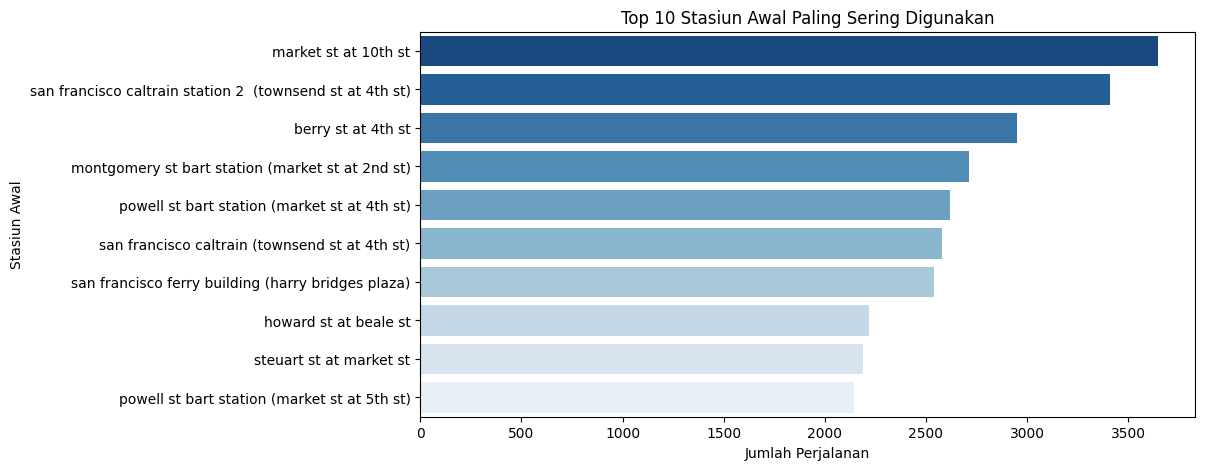

In [53]:
top_start = df_clean['start_station_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_start.values, y=top_start.index, palette="Blues_r")
plt.title("Top 10 Stasiun Awal Paling Sering Digunakan")
plt.xlabel("Jumlah Perjalanan")
plt.ylabel("Stasiun Awal")
plt.show()

/tmp/ipython-input-1081658018.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_end.values, y=top_end.index, palette="Greens_r")


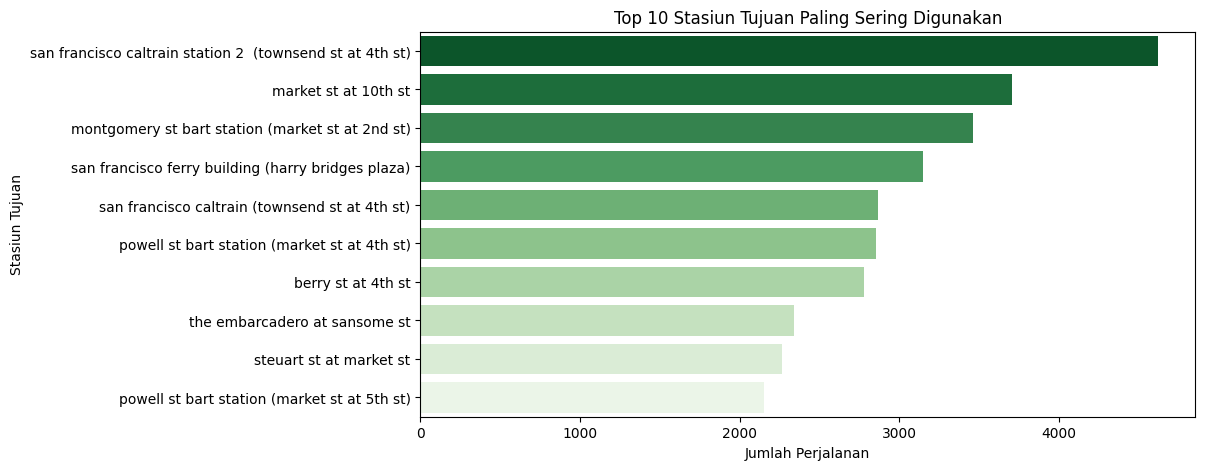

In [52]:
top_end = df_clean['end_station_name'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_end.values, y=top_end.index, palette="Greens_r")
plt.title("Top 10 Stasiun Tujuan Paling Sering Digunakan")
plt.xlabel("Jumlah Perjalanan")
plt.ylabel("Stasiun Tujuan")
plt.show()

In [ ]:
from google.colab import files

# Simpan ke CSV
df_clean.to_csv("fordgobike_clean.csv", index=False, sep=";")

# Download
files.download("fordgobike_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>